In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\gaurav\Orange Cap 2023.csv")
df1 = pd.read_csv(r"C:\Users\Lenovo\Desktop\gaurav\Orange Cap 2024.csv")
df.head()
df =pd.concat([df,df1])
df.dropna(inplace=True)
X = df.drop(columns=["Strike Rate"])
df.dropna(inplace=True)
y = df[["Strike Rate"]]
cat = X.select_dtypes(include=["object"]).columns
num = X.select_dtypes(exclude=["object"]).columns
df.fillna(df.mean(numeric_only=True),inplace=True)
df.dropna(inplace=True)
df.head()
# import matplotlib.pyplot as plt
# player_name = "F du Plessis"
# player_data = df[df["Player Name"]==player_name]
# plt.bar(player_data["Player Name"],player_data["Strike Rate"])
# plt.title("strike rate of f du pl")
# plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13724\918564235.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=["object"]).columns


,Player Name,Team Name,Total runs,Year,Matches Played,Innings,Not Outs,Highest Score,Average,Balls Faced,Strike Rate,0,50,100,4s,6s
0,Shubman Gill,GT,890,2023,17,17,2,129,59.33,564,157.80,1,4,3,85,33
1,F du Plessis,RCB,730,2023,14,14,1,84,56.15,475,153.68,0,8,0,60,36
2,DP Conway,CSK,672,2023,16,15,2,92*,51.69,481,139.70,1,6,0,77,18
3,V Kohli,RCB,639,2023,14,14,2,101*,53.25,457,139.82,1,6,2,65,16
4,YBK Jaiswal,RR,625,2023,14,14,1,124,48.07,382,163.61,1,5,1,82,26


In [21]:
pre = ColumnTransformer(transformers=[
    ("caat",OneHotEncoder(drop="first",handle_unknown="ignore"),cat),
    ("num",StandardScaler(),num)
])
pre
df.head()

,Player Name,Team Name,Total runs,Year,Matches Played,Innings,Not Outs,Highest Score,Average,Balls Faced,Strike Rate,0,50,100,4s,6s
0,Shubman Gill,GT,890,2023,17,17,2,129,59.33,564,157.80,1,4,3,85,33
1,F du Plessis,RCB,730,2023,14,14,1,84,56.15,475,153.68,0,8,0,60,36
2,DP Conway,CSK,672,2023,16,15,2,92*,51.69,481,139.70,1,6,0,77,18
3,V Kohli,RCB,639,2023,14,14,2,101*,53.25,457,139.82,1,6,2,65,16
4,YBK Jaiswal,RR,625,2023,14,14,1,124,48.07,382,163.61,1,5,1,82,26


In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,random_state=42)
X_train
model.fit(X_train,y_train)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('liner', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('caat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [25]:
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
model = Pipeline(steps=[
    ("pre",pre),
    ("liner",RandomForestRegressor())
])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('liner', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('caat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [27]:
y_pred = model.predict(X_test)
y_pred
acc = r2_score(y_test,y_pred)
print(mean_squared_error(y_test,y_pred))
acc

1099.6905450716663


C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


0.49704166631011604

In [47]:
X.head()

,Total runs,Matches Played,Innings,Not Outs,Highest Score,Average,Balls Faced,zero,five,hun,for,six
0,890,17,17,2,129,59.33,564,1,4,3,85,33
1,730,14,14,1,84,56.15,475,0,8,0,60,36
2,672,16,15,2,92*,51.69,481,1,6,0,77,18
3,639,14,14,2,101*,53.25,457,1,6,2,65,16
4,625,14,14,1,124,48.07,382,1,5,1,82,26


In [64]:
X.columns
# print(live.dtypes)

Index(['Player Name', 'Team Name', 'Total runs', 'Year', 'Matches Played',
       'Innings', 'Not Outs', 'Highest Score', 'Average', 'Balls Faced', '0',
       '50', '100', '4s', '6s'],
      dtype='str')

In [70]:
print(X.dtypes)

Player Name           str
Team Name             str
Total runs          int64
Year                int64
Matches Played      int64
Innings             int64
Not Outs            int64
Highest Score         str
Average           float64
Balls Faced         int64
0                   int64
50                  int64
100                 int64
4s                  int64
6s                  int64
dtype: object


Prediction: 158.9383999999999
Chance: high chance and definitely


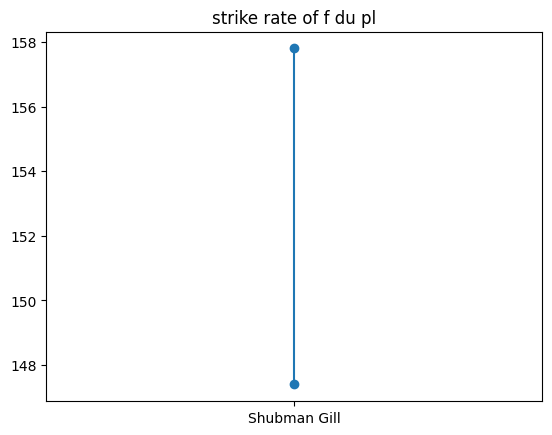

In [34]:
live = pd.DataFrame({
'Player Name':['Shubman Gill'],
'Team Name':['GT'],
'Total runs':[890],
'Year':[2023],
'Matches Played':[17],
'Innings':[17],
'Not Outs':[2],
'Highest Score':['129'],   # 👈 string
'Average':[59.33],
'Balls Faced':[564],
'0':[1],
'50':[4],
'100':[3],
'4s':[85],
'6s':[33]


})

live = live[X.columns]

prediction = model.predict(live)
# def f():
#     if prediction<130:
#         return "little chance"
#     else:
#     return "high chance and difinatly"
# print("Predicted Value:", prediction)
def f(x):
    return "little chance" if x < 130 else "high chance and definitely"

result = pd.Series(prediction).apply(f)

print("Prediction:", prediction[0])
print("Chance:", result[0])

import matplotlib.pyplot as plt
player_name = live["Player Name"].iloc[0]
player_data = df[df["Player Name"]==player_name]
plt.plot(player_data["Player Name"],player_data["Strike Rate"])
plt.scatter(player_data["Player Name"],player_data["Strike Rate"])
plt.title("strike rate of f du pl")
plt.show()

In [49]:
live = pd.DataFrame({'Total runs':[890], 
                     'Matches Played':[17],
                     'Innings':[17], 
                     'Not Outs':[2], 
                     'Highest Score':[129], 
                     'Average':[59.33], 
                     'Balls Faced':[564],
                     'zero':[1], 
                     'five':[4], 
                     'hun':[3], 
                     'for':[85], 
                     'six':[33]})

# live = live[X.columns]

prediction = model.predict(live)

print("Predicted Value:", prediction)
 

TypeError: '<' not supported between instances of 'int' and 'str'

In [51]:
live = pd.DataFrame({
    'Total runs':[890],      # Integer
    'Matches Played':[17],   # Integer
    'for':[85],              # Integer (but check your training data!)
    'six':[33]               # Integer
})

# Force columns to string if the Encoder expects strings
live['some_column'] = live['some_column'].astype(str)

# OR force everything to numeric if that's what was trained
live['for'] = pd.to_numeric(live['for'])

KeyError: 'some_column'

In [53]:
"""Problem 1: Tax Calculator (Using if-elif) 
 Income ≤ 2,50,000 → No Tax 
 Income ≤ 5,00,000 → 5% Tax 
 Income ≤ 10,00,000 → 20% Tax 
 Income > 10,00,000 → 30% Tax"""
i = int(input("enter"))
if i<=250000:
    print("no tax")
elif i<=500000:
    print("5% tax",i*0.05)
elif i<=1000000:
    print("20% tax",i*0.2)
else:
    print("30% tax",i*0.3)

enter 5000


no tax
